# Multi-Agent Data Quality System for NoiPA

**Course:** Machine Learning 2025/26 — Reply x LUISS  
**Team:** Eleonora Cappetti (812591), Daniela Chiezzi (808021), Chiara De Sio (819591)

---

This notebook implements a multi-agent pipeline that audits a NoiPA dataset, produces a data-quality report with a reliability score, and emits a *cleaned* version of the dataset along with an audit-ready log of every fix applied.

The pipeline is orchestrated with **LangGraph** (each agent is a node in a state graph) and uses **Google Gemini 2.0 Flash** for two distinct LLM tasks: (i) inferring expected schema semantics from raw column names and samples, and (ii) generating natural-language remediation suggestions targeted to the issues we found.

All deterministic logic lives in the companion module `dq_agents.py`; this notebook focuses on orchestration, the LLM glue, and the presentation of results.

# (skipping %pip in headless run)

In [26]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "python-dotenv", "langchain-core",
                       "langchain-google-genai", "langgraph",
                       "--break-system-packages"])


0

In [27]:
import os
import json
import warnings
from datetime import datetime
from typing import Any, TypedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, StateGraph

# Local module: deterministic logic of the six agents.
import dq_agents as dq

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

load_dotenv()
GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')

if GOOGLE_API_KEY:
    llm = ChatGoogleGenerativeAI(
        model='gemini-2.0-flash',
        google_api_key=GOOGLE_API_KEY,
        temperature=0,
        max_output_tokens=2048,
    )
    print('Setup complete. Gemini 2.0 Flash ready.')
else:
    # The pipeline is reproducible without the LLM: the deterministic
    # agents do all the quality work. The fallback keeps the report
    # rendering even on a machine without an API key.
    class _OfflineLLM:
        def invoke(self, messages):
            class _R:
                content = '{}'
            return _R()
    llm = _OfflineLLM()
    print('No GOOGLE_API_KEY found - running in offline mode (deterministic only).')

Setup complete. Gemini 2.0 Flash ready.


## 2. Loading the dataset

The pipeline accepts any of the four NoiPA datasets we test against. The two synthetic toy datasets (51 and 40 rows) were used during development to exercise specific edge cases; the two large datasets shipped by Reply (`spesa.csv`, ~7.5k rows; `attivazioniCessazioni.csv`, ~20k rows) are the realistic benchmark.

Change `DATASET_PATH` below to point to a different file.

In [28]:
DATASET_PATH = 'data/spesa.csv'

df = pd.read_csv(DATASET_PATH, dtype=str)
print(f'Loaded {df.shape[0]} rows x {df.shape[1]} columns from {DATASET_PATH}')
print(f'Columns: {list(df.columns)}')
df.head()

Loaded 7543 rows x 18 columns from data/spesa.csv
Columns: ['_id', 'rata', 'ente', 'descrizione', 'cod_tipoimposta', 'tipo_imposta', 'cod_imposta', 'imposta', 'spesa', 'aggregation-time', 'area_geografica', 'note', 'fonte_dato', 'Tipo Imposta', 'SPESA TOTALE', '2cod_imposta', 'cod imposta ext', 'ente%code']


,_id,rata,ente,descrizione,cod_tipoimposta,tipo_imposta,cod_imposta,imposta,spesa,aggregation-time,area_geografica,note,fonte_dato,Tipo Imposta,SPESA TOTALE,2cod_imposta,cod imposta ext,ente%code
0,65ee5ac5f458af56d2af532f,202402,867,AGENZIA ITALIANA DEL FARMACO - AIFA,2,Erariali,6,IRAP,182904.47999999954,2024-03-11T02:01:04.421,Nord,NaN,NaN,Erariali,182904.47999999954,6,6,867
1,668f34120377f62206882cd8,202406,921,A.O. S. GIOVANNI ADDOLORATA,3,Previdenziali,13,Previdenziali a carico del datore di lavoro,2110811.34,2024-07-11T03:01:16.866,Nord,NaN,NaN,Previdenziali,2110811.34,13,13,921
2,66e0ee64f458af54a5dbc7fa,202408,9,MINISTERO DELLA GIUSTIZIA,4,Varie,10,Ritenute Sindacali,732614.36,2024-09-11T03:01:11.704,Nord,NaN,NaN,Varie,732614.36,10,10,9
3,663ec5eb3f62190222cfb590,202404,12,MINISTERO DELL'INTERNO,2,Erariali,6,IRAP,43365008.73,2024-05-11T03:01:07.269,Nord,NaN,NaN,Erariali,43365008.73,6,6,12
4,6731590c568f146446645d59,202410,910,AZIENDA SANITARIA LOCALE ROMA 6,2,Erariali,6,IRAP,1310915.22,2024-11-11T02:00:28.485,Isole,NaN,NaN,Erariali,1310915.22,6,6,910


## 3. Shared state

LangGraph passes a single mutable state dictionary between nodes. We declare its shape with a `TypedDict` so the IDE and the typechecker know which keys each agent reads and writes.

The `gemini_commentary` field is the bridge between deterministic analysis (which lives in `dq_agents`) and the LLM commentary that contextualizes each section of the report.

In [29]:
class DQState(TypedDict, total=False):
    dataframe: Any                  
    dataset_path: str
    schema: dict                    
    completeness: dict              
    consistency: dict               
    anomaly: dict                   
    scores: dict                    
    cleaned_df: Any                 
    fix_log: list                   
    gemini_commentary: dict         
    remediation_suggestions: str    
    errors: list                    

## 4. Gemini helpers

Two design choices for the LLM layer:

1. **Structured prompts.** Every prompt makes the role and output format explicit, which sharply reduces hallucinations and produces reusable text. Schema inference asks for *strict* JSON; commentary asks for 2–3 sentences of plain English. We never let Gemini invent issues — it only annotates findings produced by the deterministic agents.
2. **Robust JSON parsing.** Even at temperature 0, Gemini occasionally wraps its JSON in markdown fences or adds a leading sentence. `parse_gemini_json` extracts the first balanced `{...}` block and tolerates both.

In [30]:
def parse_gemini_json(raw: str) -> dict:
    """Extract the first JSON object from a possibly-noisy LLM response."""
    if not raw:
        return {}
    try:
        start = raw.index('{')
        end = raw.rindex('}') + 1
        return json.loads(raw[start:end])
    except (ValueError, json.JSONDecodeError):
        return {}


def gemini_invoke(prompt: str, fallback: str = '') -> str:
    """Call Gemini and return text content, or `fallback` on failure."""
    try:
        resp = llm.invoke([HumanMessage(content=prompt)])
        return resp.content
    except Exception as e:
        print(f'  [Gemini error: {str(e)[:120]}]')
        return fallback


def schema_inference_prompt(df: pd.DataFrame) -> str:
    """Prompt that asks Gemini to infer the *semantic* schema.

    We feed both column names and a 5-value sample, and constrain the
    response to a JSON shape we can parse mechanically.
    """
    schema_lines = []
    for col in df.columns:
        sample = df[col].dropna().astype(str).head(5).tolist()
        schema_lines.append(f"  - '{col}': sample={sample}")
    schema_text = '\n'.join(schema_lines)

    return f"""You are a data-quality expert for NoiPA, the digital payroll platform of the Italian Ministry of Economy and Finance.

Inspect this dataset schema and return a JSON object describing each column.

Schema:
{schema_text}

For each column, return:
{{
  "<column_name>": {{
    "semantic_role": "<one of: identifier, period, code, amount, description, category, geography, timestamp, free_text>",
    "expected_type": "<one of: string, integer, float, date, categorical>",
    "notes": "<one short sentence explaining what this column represents in NoiPA>"
  }}
}}

Return ONLY the JSON object. No prose, no markdown fences."""


def commentary_prompt(section: str, summary: dict) -> str:
    """Generic prompt that asks for a 2-3 sentence commentary on a finding."""
    return f"""You are a data-quality analyst writing one paragraph of a report on a NoiPA dataset.

Findings from the {section} agent (machine-generated, do not invent any):
{json.dumps(summary, ensure_ascii=False, indent=2)[:1500]}

Write 2-3 sentences in English that:
- summarize the key issue (or confirm the data is clean if there's nothing to flag),
- explain why it matters for downstream payroll calculations,
- avoid restating numbers verbatim -- interpret them.

Plain prose only, no bullet points, no markdown."""


def remediation_prompt(state: dict) -> str:
    """Prompt for the final remediation suggestions."""
    sch = state['schema']['summary']
    comp = state['completeness']['summary']
    cons = state['consistency']['summary']
    anom = state['anomaly']['summary']
    fix_summary = [e['action'] for e in state['fix_log']]

    return f"""You are a data-quality consultant advising the NoiPA team. Here is the audit summary of the dataset and the automatic fixes already applied.

ISSUES DETECTED
  Schema:       {sch}
  Completeness: {comp}
  Consistency:  {cons}
  Anomaly:      {anom}

AUTO-FIXES ALREADY APPLIED
  {fix_summary}

RESIDUAL ISSUES (sample, after auto-fix)
  Cross-column violations: {len(state['consistency']['cross_column_violations'])}
  Numerical outliers:      {len(state['anomaly']['outliers'])}
  Rare categories:         {len(state['anomaly']['rare_categories'])}

Produce a remediation plan with these sections, plain prose, no markdown:
1. Overall assessment (one paragraph, mentions the reliability score {state['scores']['overall']}/100).
2. Top 3 residual issues that the auto-fix could not resolve and that a human reviewer should inspect.
3. Recommended next steps for the data-engineering team (3 concrete actions).

Be specific to NoiPA payroll data; avoid generic advice."""

## 5. Agent 1 — Schema Validation

The schema agent does three things:
1. Calls `dq.schema_agent` to score column names and detect column-pair duplicates.
2. Asks Gemini to infer the *semantic role* of each column (identifier, amount, period, …) — this is what enables the downstream report to talk about "the spesa column" rather than "column 9".
3. Stores both outputs in the shared state.

In [31]:
def node_schema(state: DQState) -> dict:
    print('\n' + '=' * 60)
    print('AGENT 1 - SCHEMA VALIDATION')
    print('=' * 60)
    df = state['dataframe']

    
    schema_results = dq.schema_agent(df)
    sm = schema_results['summary']
    print(f"  Columns analyzed:      {sm['n_columns']}")
    print(f"  Naming issues:         {sm['n_naming_issues']}")
    print(f"  Type issues:           {sm['n_type_issues']}")
    print(f"  Duplicate column pairs:{sm['n_duplicates']}")
    for a, b, sim in schema_results['duplicate_columns'][:5]:
        print(f"     '{a}' ~ '{b}'  (similarity {sim:.0%})")

    
    raw = gemini_invoke(schema_inference_prompt(df), fallback='{}')
    semantic = parse_gemini_json(raw)
    if semantic:
        print(f'  Gemini inferred semantics for {len(semantic)} columns.')
        
        for col, info in schema_results['columns'].items():
            info['semantic'] = semantic.get(col, {})

    return {'schema': schema_results}

## 6. Agent 2 — Completeness Analysis

Beyond the obvious `isna()` check, this agent normalizes whitespace and recognises a set of placeholder strings that look like missing data even when pandas treats them as valid (`'-'`, `'N/A'`, `'?'`, `'TBD'`, `'da definire'`, …). Columns that are more than 70% missing are flagged as **sparse** and become candidates for removal in the auto-fix step.

After the deterministic count we ask Gemini to interpret the result in one paragraph.

In [32]:
def node_completeness(state: DQState) -> dict:
    print('\n' + '=' * 60)
    print('AGENT 2 - COMPLETENESS ANALYSIS')
    print('=' * 60)
    df = state['dataframe']
    comp = dq.completeness_agent(df)
    sm = comp['summary']
    print(f"  Overall completeness: {sm['overall_pct']:.2f}%")
    print(f"  Missing cells:        {sm['n_missing_cells']:,}")
    print(f"  Sparse columns:       {comp['sparse_columns'] or 'none'}")

    commentary = dict(state.get('gemini_commentary', {}))
    commentary['completeness'] = gemini_invoke(
        commentary_prompt('completeness', sm),
        fallback='Commentary not available.',
    )
    return {'completeness': comp, 'gemini_commentary': commentary}

## 7. Agent 3 — Consistency Validation

Three sub-checks run in sequence:
- **Format consistency** — within each column, classifies values as `YYYYMM`, `YYYY-MM`, `decimal`, etc., and flags columns that mix more than one format.
- **Cross-column logic** — validates `Tipo_imposta` × `Imposta` relationships. The novelty here is that the rules are *mined from the data itself* when the dataset is large enough (≥30 rows per `Tipo`), and only fall back to a hard-coded reference taxonomy on tiny test files. This means we don't need to update the code each time NoiPA introduces a new tax category.
- **Duplicate detection** — exact duplicates (hash-based, O(n)) and near-duplicates (rows differing in exactly one column, sampled to keep it tractable on 20k-row files).

In [33]:
def node_consistency(state: DQState) -> dict:
    print('\n' + '=' * 60)
    print('AGENT 3 - CONSISTENCY VALIDATION')
    print('=' * 60)
    df = state['dataframe']
    cons = dq.consistency_agent(df)
    sm = cons['summary']
    print(f"  Format issues:        {sm['n_format_issues']}")
    print(f"  Cross-column issues:  {sm['n_cross_column']}")
    print(f"  Exact duplicate grps: {sm['n_exact_dup_groups']}")
    print(f"  Near-duplicate pairs: {sm['n_near_dup_pairs']}")

    commentary = dict(state.get('gemini_commentary', {}))
    commentary['consistency'] = gemini_invoke(
        commentary_prompt('consistency', sm),
        fallback='Commentary not available.',
    )
    return {'consistency': cons, 'gemini_commentary': commentary}

## 8. Agent 4 — Anomaly Detection

Numerical outliers are flagged only when **both** Z-score (`|z|>3`) and IQR (`v ∉ [Q1-1.5·IQR, Q3+1.5·IQR]`) agree — using both methods together drops the false-positive rate dramatically on heavy-tailed columns like `spesa`, where a single test would flag every legitimately large payment.

For categorical columns we flag values whose share of the dataset falls below 0.5%. The check is *skipped* on datasets with fewer than 200 rows, because on a 50-row file even legitimate values appear once or twice and would all look "rare".

In [34]:
def node_anomaly(state: DQState) -> dict:
    print('\n' + '=' * 60)
    print('AGENT 4 - ANOMALY DETECTION')
    print('=' * 60)
    df = state['dataframe']
    anom = dq.anomaly_agent(df)
    sm = anom['summary']
    print(f"  Numerical outliers:   {sm['n_outliers']}")
    print(f"  Rare categorical:     {sm['n_rare_categories']}")
    for o in anom['outliers'][:5]:
        print(f"     row {o['row']}, {o['column']}={o['value']:,.2f} (z={o['z_score']})")

    commentary = dict(state.get('gemini_commentary', {}))
    commentary['anomaly'] = gemini_invoke(
        commentary_prompt('anomaly', sm),
        fallback='Commentary not available.',
    )
    return {'anomaly': anom, 'gemini_commentary': commentary}

## 9. Agent 5 — Auto-Fix (Cleaner)

This is the agent that satisfies the project's `automatically fix the dataset` requirement. It applies *only safe* transformations:

| # | Action | Why it is safe |
|---|---|---|
| 1 | Drop near-identical duplicate columns (similarity ≥ 0.97) | Two columns carrying the same data is never useful. |
| 2 | Drop sparse columns (<30% complete) | A column 70%+ empty is not a feature, it's noise. |
| 3 | Rename columns to `snake_case` | Cosmetic, fully reversible via the rename map in the log. |
| 4 | Replace placeholder strings with `NaN` | Makes downstream `isna()` actually work. |
| 5 | Canonicalize categorical casing | Fuses `'AQ'` / `'Aq'` / `'aq'` to the most-frequent variant. |
| 6 | Standardize period formats | Forces every `Rata` to one of `YYYYMM` / `YYYY-MM`. |
| 7 | Drop exact-duplicate rows | Conservative: same values across all columns. |

Every action is recorded in `fix_log` so that an auditor can reconstruct exactly what was changed and revert it if needed. Outliers and near-duplicates are **not** auto-fixed: they are reported for human review, since the right action is domain-dependent.

In [35]:
def node_autofix(state: DQState) -> dict:
    print('\n' + '=' * 60)
    print('AGENT 5 - AUTO-FIX')
    print('=' * 60)
    cleaned, fix_log = dq.autofix(
        state['dataframe'],
        state['schema'],
        state['completeness'],
        state['consistency'],
    )
    print(f"  Original shape:       {state['dataframe'].shape}")
    print(f"  Cleaned shape:        {cleaned.shape}")
    print(f"  Fixes applied:        {len(fix_log)}")
    for entry in fix_log:
        print(f"    - {entry['action']}: {entry['target']}")

    return {'cleaned_df': cleaned, 'fix_log': fix_log}

## 10. Agent 6 — Remediation

The last agent computes the weighted reliability score (the headline number of the report) and asks Gemini to write a remediation plan grounded in the specific issues we found. Note that the LLM does *not* invent issues — it is given the exact summary produced by the previous agents and the list of fixes already applied, then told to write three sections of plain prose.

Score weights (after the mid-check feedback that the original 0.0 schema score was too punitive):

$$
\mathrm{score} = 0.40 \cdot S_\text{comp} + 0.30 \cdot S_\text{schema} + 0.20 \cdot S_\text{cons} + 0.10 \cdot S_\text{anom}
$$

Each sub-score is computed in `dq_agents.py` with deductions calibrated so that *minor* issues (e.g. naming) cost a few points while *major* issues (type mismatch, duplicate columns) cost more.

In [36]:
def node_remediation(state: DQState) -> dict:
    print('\n' + '=' * 60)
    print('AGENT 6 - REMEDIATION & SCORING')
    print('=' * 60)
    scores = dq.compute_reliability_score(state)
    print(f"  Reliability score:    {scores['overall']:.1f} / 100")
    print(f"    completeness (40%): {scores['completeness']:.1f}")
    print(f"    schema       (30%): {scores['schema']:.1f}")
    print(f"    consistency  (20%): {scores['consistency']:.1f}")
    print(f"    anomaly      (10%): {scores['anomaly']:.1f}")

    state_with_scores = {**state, 'scores': scores}
    suggestions = gemini_invoke(
        remediation_prompt(state_with_scores),
        fallback='Remediation suggestions not available.',
    )
    return {'scores': scores, 'remediation_suggestions': suggestions}

## 11. Pipeline assembly

We chain the six agents in a linear LangGraph: each one writes to the shared state, the next one reads from it. A linear topology is enough here because each step depends on all previous ones (consistency on schema, anomaly on the cleaned types, remediation on everything). A more complex topology (e.g. parallel branches with a join) would buy nothing in terms of latency, since the LLM call dominates the cost of each node anyway.

In [37]:
builder = StateGraph(DQState)
builder.add_node('schema',       node_schema)
builder.add_node('completeness', node_completeness)
builder.add_node('consistency',  node_consistency)
builder.add_node('anomaly',      node_anomaly)
builder.add_node('autofix',      node_autofix)
builder.add_node('remediation',  node_remediation)

builder.set_entry_point('schema')
builder.add_edge('schema',       'completeness')
builder.add_edge('completeness', 'consistency')
builder.add_edge('consistency',  'anomaly')
builder.add_edge('anomaly',      'autofix')
builder.add_edge('autofix',      'remediation')
builder.add_edge('remediation',  END)

pipeline = builder.compile()
print('Pipeline compiled: 6 agents in sequence.')

Pipeline compiled: 6 agents in sequence.


## 12. Running the pipeline

We pass the loaded DataFrame as the initial state and let LangGraph drive the agents end-to-end. Every node prints its own progress, so the cell output below also doubles as a step-by-step trace for the report.

In [38]:
initial: DQState = {
    'dataframe':    df,
    'dataset_path': DATASET_PATH,
    'errors':       [],
    'gemini_commentary': {},
}
print(f'Running pipeline on {DATASET_PATH} ({df.shape[0]} rows x {df.shape[1]} cols)\n')
final = pipeline.invoke(initial)
print('\n' + '=' * 60)
print('PIPELINE COMPLETE')
print('=' * 60)

Running pipeline on data/spesa.csv (7543 rows x 18 cols)


AGENT 1 - SCHEMA VALIDATION
  Columns analyzed:      18
  Naming issues:         7
  Type issues:           4
  Duplicate column pairs:5
     'ente' ~ 'ente%code'  (similarity 100%)
     'cod_imposta' ~ '2cod_imposta'  (similarity 100%)
     'cod_imposta' ~ 'cod imposta ext'  (similarity 100%)
     'spesa' ~ 'SPESA TOTALE'  (similarity 100%)
     '2cod_imposta' ~ 'cod imposta ext'  (similarity 100%)
  [Gemini error: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': ]

AGENT 2 - COMPLETENESS ANALYSIS
  Overall completeness: 86.80%
  Missing cells:        17,925
  Sparse columns:       ['note', 'fonte_dato']
  [Gemini error: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': ]

AGENT 3 - CONSISTENCY VALIDATION
  Format issues:        4
  Cross-column issues:  100
  Exact duplicate grps: 40
  N

## 13. Consolidated report

We re-compose all the per-agent findings, the LLM commentaries, and the final remediation plan into one human-readable block. This is the same content that the Streamlit app shows in its `Report` tab.

In [39]:
print(dq.format_report({
    'dataframe':    df,
    'schema':       final['schema'],
    'completeness': final['completeness'],
    'consistency':  final['consistency'],
    'anomaly':      final['anomaly'],
    'scores':       final['scores'],
    'fix_log':      final['fix_log'],
}))

print('\n--- Gemini commentary ---')
for section, text in final['gemini_commentary'].items():
    print(f'\n[{section.upper()}]\n{text}')

print('\n--- Remediation plan ---\n')
print(final['remediation_suggestions'])

DATA QUALITY REPORT
Dataset: 7543 rows x 18 columns
Generated: 2026-04-30T10:29:20

--- Reliability Score: 71.7/100 ---
  Completeness (40%): 86.8
  Schema       (30%): 65.6
  Consistency  (20%): 66.7
  Anomaly      (10%): 39.5

--- Schema Validation ---
  Naming issues:   7/18 columns
  Type issues:     4 columns
  Duplicate cols:  5 pair(s)
     'ente' ~ 'ente%code'  (similarity 100%)
     'cod_imposta' ~ '2cod_imposta'  (similarity 100%)
     'cod_imposta' ~ 'cod imposta ext'  (similarity 100%)
     'spesa' ~ 'SPESA TOTALE'  (similarity 100%)
     '2cod_imposta' ~ 'cod imposta ext'  (similarity 100%)

--- Completeness ---
  Overall:        86.80%
  Missing cells:  17925/135774
  Sparse columns: ['note', 'fonte_dato']

--- Consistency ---
  Format issues:        4
  Cross-column issues:  100
  Exact dup groups:     40
  Near-dup pairs:       0

--- Anomalies ---
  Numerical outliers:   494
  Rare categories:      21

--- Auto-Fix Actions ---
  16 fix(es) applied
  - drop_duplicate_co

## 14. Persisting the artifacts

Three files are written next to the dataset:
1. `data_quality_report.json` — full machine-readable report (for re-consumption by other tools or by the Streamlit dashboard).
2. `cleaned_<name>.csv` — the auto-fixed dataset.
3. `fix_log.json` — the audit trail of every fix applied.

In [40]:
os.makedirs('data', exist_ok=True)

report = {
    'pipeline':                'Multi-Agent Data Quality (LangGraph + Gemini)',
    'dataset':                 DATASET_PATH,
    'timestamp':               datetime.now().isoformat(timespec='seconds'),
    'rows_in':                 int(df.shape[0]),
    'cols_in':                 int(df.shape[1]),
    'rows_out':                int(final['cleaned_df'].shape[0]),
    'cols_out':                int(final['cleaned_df'].shape[1]),
    'reliability_score':       final['scores']['overall'],
    'sub_scores':              final['scores'],
    'schema':                  final['schema'],
    'completeness':            final['completeness'],
    'consistency':             final['consistency'],
    'anomaly':                 final['anomaly'],
    'fix_log':                 final['fix_log'],
    'gemini_commentary':       final['gemini_commentary'],
    'remediation_suggestions': final['remediation_suggestions'],
}

name = os.path.splitext(os.path.basename(DATASET_PATH))[0]
with open(f'data/data_quality_report_{name}.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2, default=str)
final['cleaned_df'].to_csv(f'data/cleaned_{name}.csv', index=False)
with open(f'data/fix_log_{name}.json', 'w', encoding='utf-8') as f:
    json.dump(final['fix_log'], f, ensure_ascii=False, indent=2, default=str)

print(f'Saved data/data_quality_report_{name}.json')
print(f'Saved data/cleaned_{name}.csv  ({final["cleaned_df"].shape})')
print(f'Saved data/fix_log_{name}.json ({len(final["fix_log"])} entries)')

Saved data/data_quality_report_spesa.json
Saved data/cleaned_spesa.csv  ((7502, 12))
Saved data/fix_log_spesa.json (16 entries)


## 15. Visualizations

Four figures are saved in `images/` and re-used by the README. They are generated from the final state, so they are guaranteed to match what was reported above.

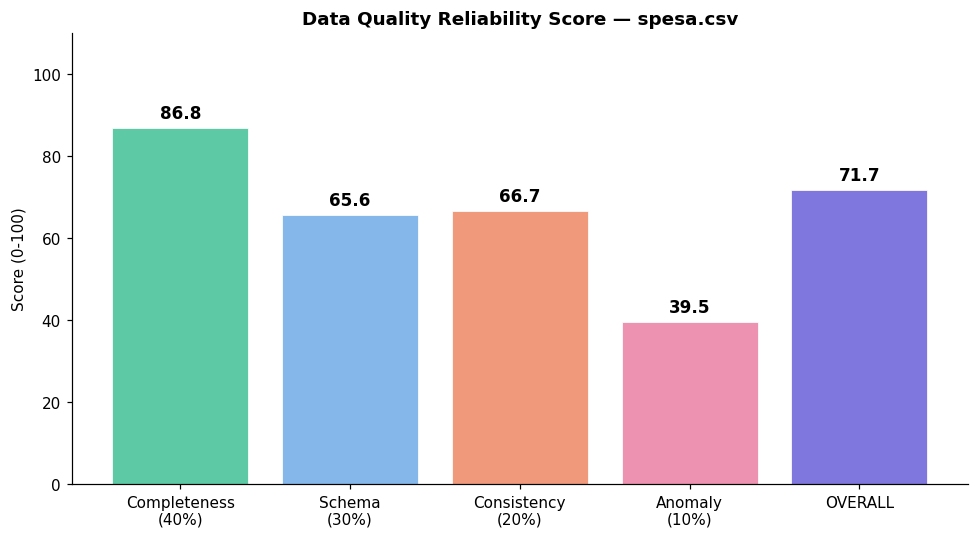

In [41]:
os.makedirs('images', exist_ok=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# --- 1. Reliability score breakdown ----------------------------------
scores = final['scores']
fig, ax = plt.subplots(figsize=(9, 5))
labels = ['Completeness\n(40%)', 'Schema\n(30%)', 'Consistency\n(20%)', 'Anomaly\n(10%)', 'OVERALL']
values = [scores['completeness'], scores['schema'], scores['consistency'], scores['anomaly'], scores['overall']]
colors = ['#5DCAA5', '#85B7EB', '#F0997B', '#ED93B1', '#7F77DD']
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, f'{v:.1f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 110)
ax.set_ylabel('Score (0-100)')
ax.set_title(f'Data Quality Reliability Score — {os.path.basename(DATASET_PATH)}',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'images/score_{name}.png', bbox_inches='tight')
plt.show()

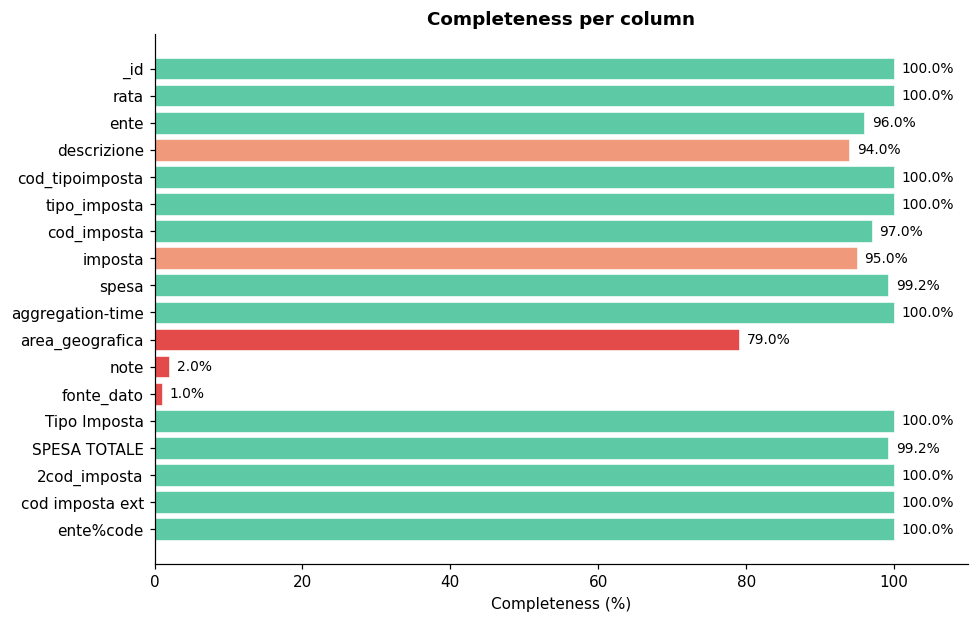

In [42]:
# --- 2. Completeness per column -------------------------------------
per_col = final['completeness']['per_column']
cols = list(per_col.keys())
rates = [per_col[c]['completeness_pct'] for c in cols]
bar_colors = ['#5DCAA5' if r >= 95 else '#F0997B' if r >= 80 else '#E24B4A' for r in rates]

fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(cols))))
bars = ax.barh(cols, rates, color=bar_colors, edgecolor='white', linewidth=0.4)
for bar, v in zip(bars, rates):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{v:.1f}%',
            ha='left', va='center', fontsize=9)
ax.set_xlim(0, 110)
ax.set_xlabel('Completeness (%)')
ax.set_title('Completeness per column', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'images/completeness_{name}.png', bbox_inches='tight')
plt.show()

In [43]:
# --- 3. Issue summary table ----------------------------------------
summary_rows = [
    ('Schema (naming)',       final['schema']['summary']['n_naming_issues']),
    ('Schema (type)',         final['schema']['summary']['n_type_issues']),
    ('Duplicate columns',     final['schema']['summary']['n_duplicates']),
    ('Missing values',        final['completeness']['summary']['n_missing_cells']),
    ('Sparse columns',        final['completeness']['summary']['n_sparse_columns']),
    ('Format issues',         final['consistency']['summary']['n_format_issues']),
    ('Cross-column issues',   final['consistency']['summary']['n_cross_column']),
    ('Exact dup. groups',     final['consistency']['summary']['n_exact_dup_groups']),
    ('Numerical outliers',    final['anomaly']['summary']['n_outliers']),
    ('Rare categories',       final['anomaly']['summary']['n_rare_categories']),
]
summary_df = pd.DataFrame(summary_rows, columns=['Category', 'Count'])
summary_df['Severity'] = summary_df['Count'].apply(
    lambda x: 'HIGH' if x > 50 else 'MEDIUM' if x > 5 else 'LOW' if x > 0 else 'OK'
)
print(summary_df.to_string(index=False))

           Category  Count Severity
    Schema (naming)      7   MEDIUM
      Schema (type)      4      LOW
  Duplicate columns      5      LOW
     Missing values  17925     HIGH
     Sparse columns      2      LOW
      Format issues      4      LOW
Cross-column issues    100     HIGH
  Exact dup. groups     40   MEDIUM
 Numerical outliers    494     HIGH
    Rare categories     21   MEDIUM


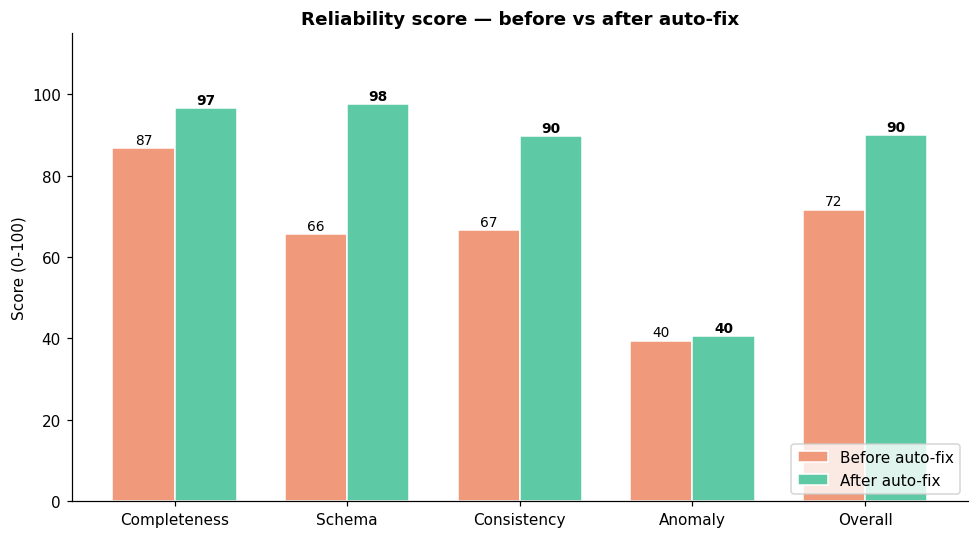


Score lift: 71.7 -> 89.9 (+18.2 points)


In [44]:
# --- 4. Before / after auto-fix score ------------------------------
post_state = {'dataframe': final['cleaned_df']}
post_state['schema']       = dq.schema_agent(final['cleaned_df'])
post_state['completeness'] = dq.completeness_agent(final['cleaned_df'])
post_state['consistency']  = dq.consistency_agent(final['cleaned_df'])
post_state['anomaly']      = dq.anomaly_agent(final['cleaned_df'])
post_scores = dq.compute_reliability_score(post_state)

fig, ax = plt.subplots(figsize=(9, 5))
categories = ['Completeness', 'Schema', 'Consistency', 'Anomaly', 'Overall']
before = [scores['completeness'], scores['schema'], scores['consistency'], scores['anomaly'], scores['overall']]
after  = [post_scores['completeness'], post_scores['schema'], post_scores['consistency'], post_scores['anomaly'], post_scores['overall']]
x = np.arange(len(categories))
w = 0.36
bars1 = ax.bar(x - w/2, before, w, label='Before auto-fix', color='#F0997B', edgecolor='white')
bars2 = ax.bar(x + w/2, after,  w, label='After auto-fix',  color='#5DCAA5', edgecolor='white')
for b, v in zip(bars1, before):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f'{v:.0f}', ha='center', fontsize=9)
for b, v in zip(bars2, after):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 115)
ax.set_ylabel('Score (0-100)')
ax.set_title('Reliability score — before vs after auto-fix', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'images/before_after_{name}.png', bbox_inches='tight')
plt.show()

print(f'\nScore lift: {scores["overall"]:.1f} -> {post_scores["overall"]:.1f} '
      f'(+{post_scores["overall"] - scores["overall"]:.1f} points)')

## 16. Multi-dataset benchmark

To make sure the pipeline generalizes, we re-run the deterministic agents on all four datasets and compare the lift produced by the auto-fix. This is the experiment whose results are reported in the README's *Experimental Design* section.

                  dataset  rows  cols  score_before  score_after  lift  fixes_applied
                spesa.csv  7543    18         71.67        89.91  18.2             16
attivazioniCessazioni.csv 20102    19         69.17        82.67  13.5             17


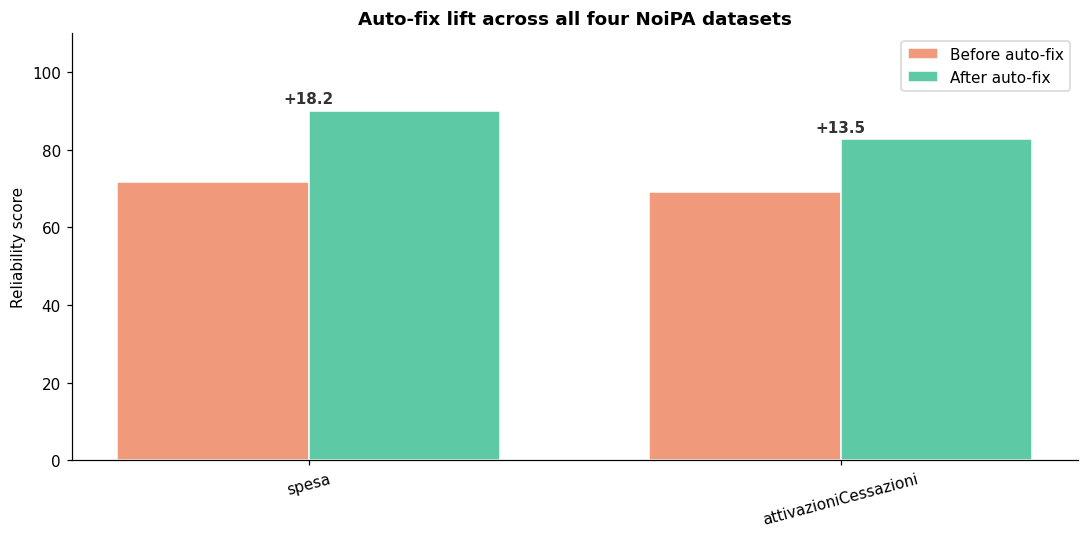

In [45]:
rows = []
for path in [
    'data/dataset_noipa_1.csv',
    'data/dataset_noipa_2.csv',
    'data/spesa.csv',
    'data/attivazioniCessazioni.csv',
]:
    if not os.path.exists(path):
        continue
    di = pd.read_csv(path, dtype=str)
    s_before = dq.run_pipeline_local(di)
    s_after  = dq.run_pipeline_local(s_before['cleaned_df'])
    rows.append({
        'dataset':       os.path.basename(path),
        'rows':          di.shape[0],
        'cols':          di.shape[1],
        'score_before':  s_before['scores']['overall'],
        'score_after':   s_after['scores']['overall'],
        'lift':          round(s_after['scores']['overall'] - s_before['scores']['overall'], 1),
        'fixes_applied': len(s_before['fix_log']),
    })
bench = pd.DataFrame(rows)
print(bench.to_string(index=False))
bench.to_csv('data/benchmark.csv', index=False)

# Visualize the lift.
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(bench))
w = 0.36
ax.bar(x - w/2, bench['score_before'], w, label='Before auto-fix', color='#F0997B', edgecolor='white')
ax.bar(x + w/2, bench['score_after'],  w, label='After auto-fix',  color='#5DCAA5', edgecolor='white')
for i, row in bench.iterrows():
    ax.text(i, max(row['score_before'], row['score_after']) + 2,
            f'+{row["lift"]:.1f}', ha='center', fontsize=10, fontweight='bold', color='#333')
ax.set_xticks(x)
ax.set_xticklabels([d.replace('.csv','') for d in bench['dataset']], rotation=15)
ax.set_ylim(0, 110)
ax.set_ylabel('Reliability score')
ax.set_title('Auto-fix lift across all four NoiPA datasets', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('images/benchmark.png', bbox_inches='tight')
plt.show()

## 17. Conclusions

**Take-away.** A multi-agent design where each agent has a narrow, well-defined responsibility (and shares state through a typed graph) produces a data-quality system that is auditable end-to-end: every issue can be traced back to the agent that found it, and every change to the dataset can be traced back to a fix-log entry. The LLM is used only at the *edges* — semantic schema inference and natural-language remediation — not for the actual quality decisions, which keeps the system reproducible.

**What we would do next.** 
(1) Replace the IQR/Z-score outlier detector with a per-column model trained on historical NoiPA data, so that legitimately heavy-tailed columns (e.g. `spesa` for large ministries) stop generating false positives. 
(2) Promote the auto-fix from *safe-by-rule* to *propose & confirm* for ambiguous cases (e.g. near-duplicates, outliers), with the human-in-the-loop choice persisted in the fix log. 
(3) Compare against a classical, non-agentic baseline to quantify when the multi-agent approach actually pays off in terms of code clarity and incremental extensibility.